# Graph Neural Networks for Molecular Activity Prediction

## Overview

In this assignment, we explore the use of Graph Neural Networks (GNNs) for predicting molecular activity against HIV.

The task is formulated as a **graph classification problem**, where:
- Each graph represents a molecule
- Nodes correspond to atoms
- Edges correspond to chemical bonds
- Each molecule is labeled as:
  - `1` – Active against HIV
  - `0` – Not active against HIV

We use the **HIV dataset from MoleculeNet**, which contains organic molecules and their biological activity labels.

The goal is to learn how molecular structure affects biological activity using different GNN architectures.

## Setup

To run this notebook, install the required packages:

```python
!py -m pip install torch torchvision torchaudio
!py -m pip install torch_geometric
!py -m pip install rdkit

In [5]:
!py -m pip install torch torchvision torchaudio

In [6]:
!py -m pip install torch_geometric

In [7]:
!py -m pip install rdkit

## Loading the Dataset and Initial Exploration

We load the HIV dataset using PyTorch Geometric. Each data point represents a molecule as a graph.

Each graph contains:
- `x`: Node features representing atomic properties
- `edge_index`: Connectivity between atoms (chemical bonds)
- `edge_attr`: Features of the bonds
- `y`: Label indicating whether the molecule is active against HIV (`1`) or not (`0`). Although the dataset provides labels in a multi-dimensional format, we use only the first label, which corresponds to HIV activity.

To better understand the dataset, we print general information such as:
- The total number of graphs (molecules)
- The number of features per node (atom)
- The number of classes

We also print individual sample from the dataset to understand their structure.

In [8]:
from torch_geometric.datasets import MoleculeNet

dataset = MoleculeNet(root="data", name="HIV")

In [9]:
print(dataset)
print("Number of graphs:", len(dataset))
print("Number of features per node:", dataset.num_features)
print("Number of classes:", dataset.num_classes)

HIV(41120)
Number of graphs: 41120
Number of features per node: 9
Number of classes: 2


In [10]:
data = dataset[0]

print(data)
print("Has edge_attr?", data.edge_attr is not None)

Data(x=[19, 9], edge_index=[2, 40], edge_attr=[40, 3], smiles='CCC1=[O+][Cu-3]2([O+]=C(CC)C1)[O+]=C(CC)CC(CC)=[O+]2', y=[1, 1])
Has edge_attr? True


In [11]:
import torch

labels = torch.cat([d.y for d in dataset]).view(-1)

labels = labels.long()

num_total = len(labels)
num_active = (labels == 1).sum().item()
num_inactive = (labels == 0).sum().item()

percent_active = 100 * num_active / num_total
percent_inactive = 100 * num_inactive / num_total

print(f"Total samples: {num_total}")
print(f"Active (1): {num_active} ({percent_active:.2f}%)")
print(f"Inactive (0): {num_inactive} ({percent_inactive:.2f}%)")

Total samples: 41120
Active (1): 1443 (3.51%)
Inactive (0): 39677 (96.49%)


## Data Visualization

To better understand the dataset, we visualize several molecules.

Each molecule is:
- Converted from graph representation to SMILES
- Rendered using RDKit
- Displayed along with its label:
  - `1` – Active against HIV
  - `0` – Not active against HIV

This step helps us qualitatively inspect molecular structures and their corresponding labels.

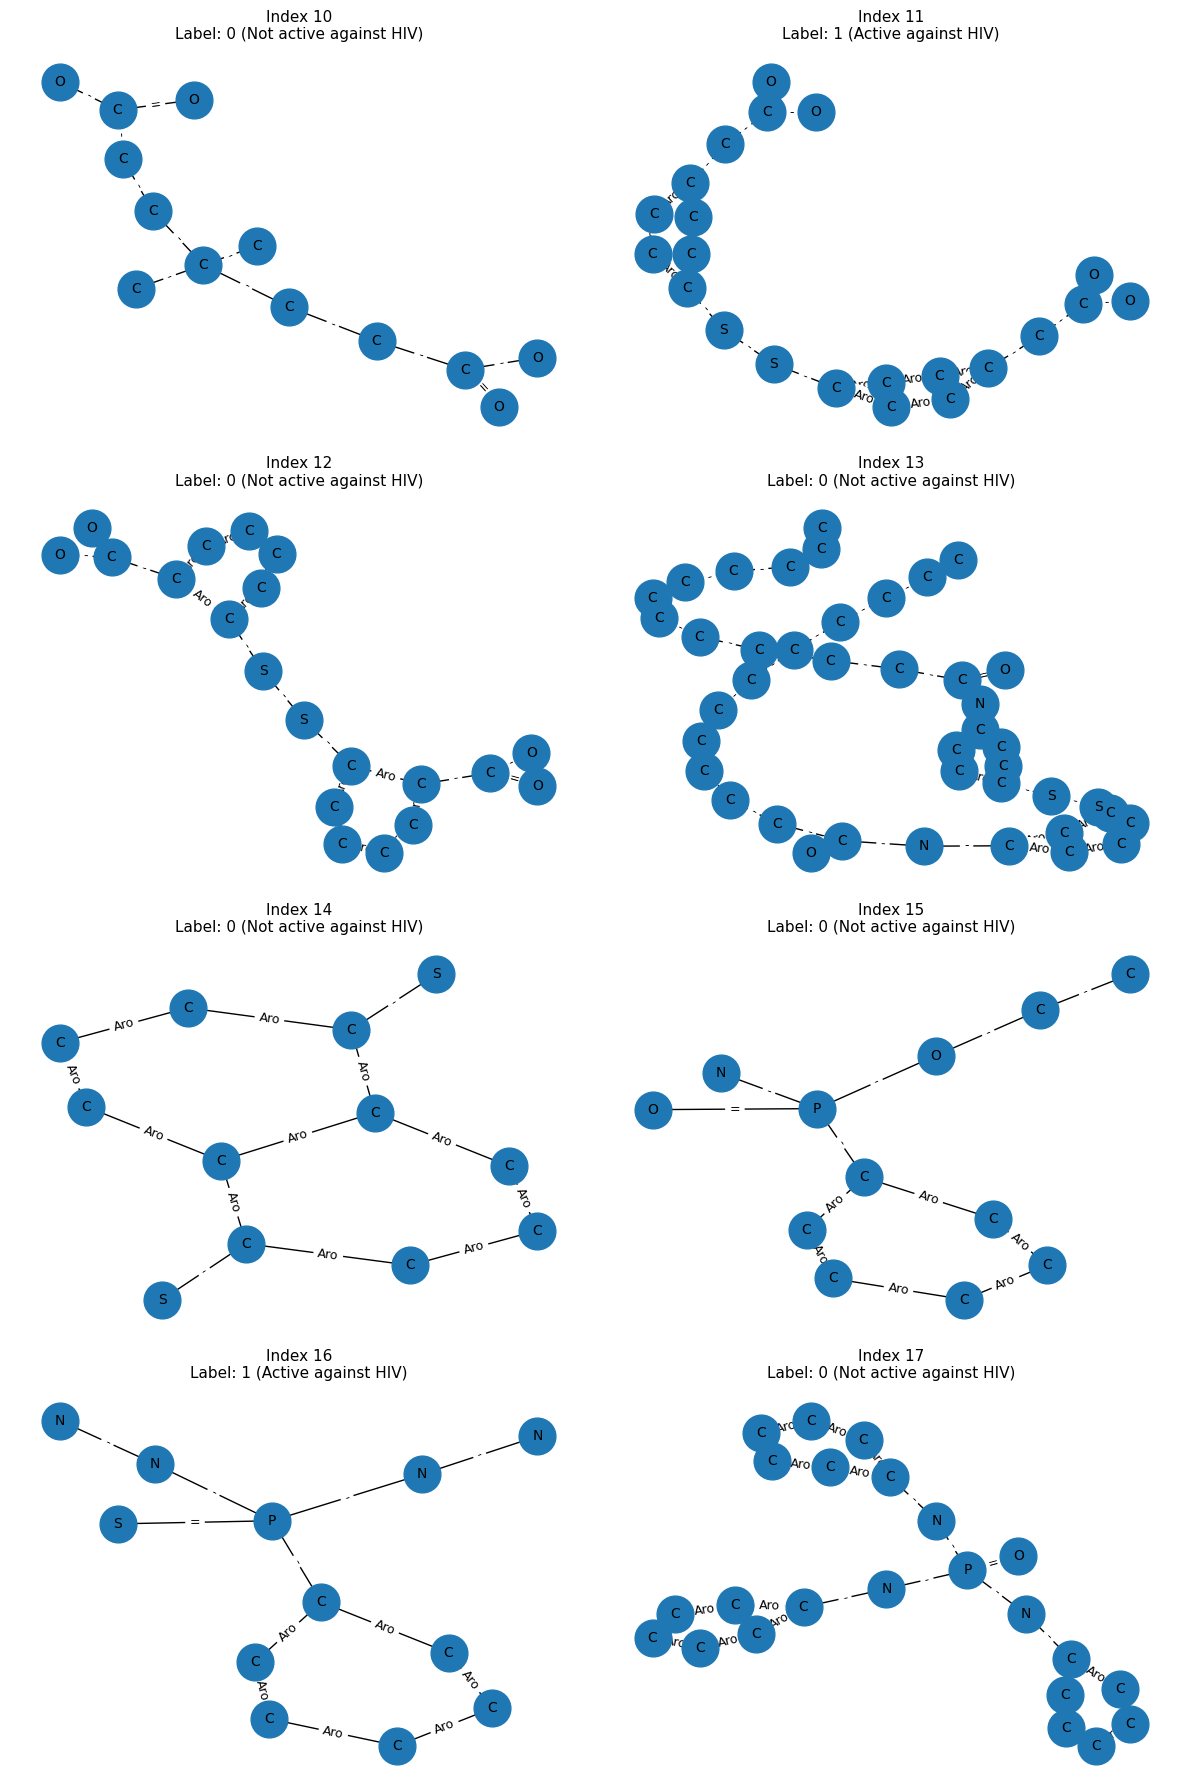

In [16]:
import matplotlib.pyplot as plt
import networkx as nx
import torch
from torch_geometric.utils import to_networkx
from IPython.display import display

# Mapping of atomic numbers to common symbols
ATOM_SYMBOLS = {
    1: "H", 5: "B", 6: "C", 7: "N", 8: "O", 9: "F",
    14: "Si", 15: "P", 16: "S", 17: "Cl", 35: "Br", 53: "I"
}

# Approximate bond-type mapping from PyG categorical encoding
BOND_LABELS = {
    0: "",
    1: "-",
    2: "=",
    3: "≡",
    12: "Aro"
}

def get_atom_label(data, node_idx):
    try:
        atom_num = int(data.x[node_idx][0].item())
        return ATOM_SYMBOLS.get(atom_num, str(atom_num))
    except Exception:
        return str(node_idx)

def draw_molecule_graph(data, ax, title=""):
    G = to_networkx(data, to_undirected=True)

    node_labels = {i: get_atom_label(data, i) for i in range(data.num_nodes)}

    try:
        pos = nx.spring_layout(G, seed=42)
    except Exception:
        pos = nx.kamada_kawai_layout(G)

    nx.draw(
        G,
        pos,
        ax=ax,
        labels=node_labels,
        with_labels=True,
        node_size=700,
        font_size=10
    )

    # Try to add bond labels if edge_attr exists
    try:
        edge_labels = {}
        edge_index = data.edge_index.t().cpu().numpy()
        edge_attr = data.edge_attr.cpu().numpy() if data.edge_attr is not None else None

        if edge_attr is not None:
            seen = set()
            for k, (u, v) in enumerate(edge_index):
                pair = tuple(sorted((int(u), int(v))))
                if pair in seen:
                    continue
                seen.add(pair)

                bond_type_idx = int(edge_attr[k][0])
                bond_label = BOND_LABELS.get(bond_type_idx, str(bond_type_idx))
                if bond_label != "":
                    edge_labels[pair] = bond_label

            nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax, font_size=9)
    except Exception:
        pass

    ax.set_title(title, fontsize=11)
    ax.axis("off")


num_to_show = 8
start_idx = 10

fig, axes = plt.subplots(4, 2, figsize=(12, 18))
axes = axes.flatten()

count = 0
idx = start_idx

while count < num_to_show and idx < len(dataset):
    data = dataset[idx]
    label = int(data.y.item())
    label_text = "Active against HIV" if label == 1 else "Not active against HIV"

    draw_molecule_graph(
        data,
        axes[count],
        title=f"Index {idx}\nLabel: {label} ({label_text})"
    )

    count += 1
    idx += 1

for j in range(count, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [17]:
import torch.nn as nn
import torch.nn.functional as F

import torch_geometric as tg
import torch_geometric.datasets as tg_dt
import torch_geometric.nn as tg_nn
from torch_geometric.loader import DataLoader

import numpy as np

import random

from sklearn.metrics import precision_score, recall_score, confusion_matrix, roc_auc_score

In [18]:
def undersample_dataset(dataset, ratio=2.0, seed=42):
    random.seed(seed)

    active = []
    inactive = []

    for data in dataset:
        if int(data.y.item()) == 1:
            active.append(data)
        else:
            inactive.append(data)

    print(f"Before:")
    print(f"  Active   : {len(active)}")
    print(f"  Inactive : {len(inactive)}")

    target_inactive = int(len(active) * ratio)
    target_inactive = min(target_inactive, len(inactive))

    sampled_inactive = random.sample(inactive, target_inactive)

    new_dataset = active + sampled_inactive
    random.shuffle(new_dataset)

    print(f"\nAfter undersampling (ratio 1:{ratio}):")
    print(f"  Active   : {len(active)}")
    print(f"  Inactive : {len(sampled_inactive)}")
    print(f"  Total    : {len(new_dataset)}")

    return new_dataset

## Dataset Split

The dataset is randomly shuffled and split into training and test sets.

We use:
- 80% of the data for training
- 20% for testing

## Handling Class Imbalance (Undersampling)

The HIV dataset is highly imbalanced, with only a small fraction of molecules labeled as active. As a result, a model trained on the original data tends to favor the majority class (inactive) and may achieve high accuracy by predicting only that class, without truly learning to identify active molecules.

To address this issue, we apply **undersampling** to the training set. Specifically, we randomly remove samples from the majority class (inactive molecules) in order to increase the relative proportion of active molecules. This makes the classification task more balanced during training and encourages the model to learn meaningful patterns for detecting active compounds.

Importantly, this balancing is applied **only to the training set**. The test set was kept unchanged to ensure that model evaluation reflects the original data distribution and provides a realistic measure of performance.

In [19]:
# Train/Test split: 80/20
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

dataset = dataset.shuffle()

train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset = dataset[:train_size]
balanced_train_dataset = undersample_dataset(
    train_dataset,
    ratio=2.0
)
test_dataset = dataset[train_size:]

print(f"Train size: {len(train_dataset)}")
print(f"Test size: {len(test_dataset)}")

train_loader = DataLoader(balanced_train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

Before:
  Active   : 1164
  Inactive : 31732

After undersampling (ratio 1:2.0):
  Active   : 1164
  Inactive : 2328
  Total    : 3492
Train size: 32896
Test size: 8224


## Model Architecture

All models are based on a GraphSAGE architecture for graph classification.

### Model 1 Architecture

The model receives node features as input and updates them through two graph convolution layers.

The first layer is a `SAGEConv` layer with **max aggregation**, which emphasizes the strongest signal among neighboring nodes.  
The second layer is another `SAGEConv` layer with **mean aggregation**, which produces a smoother neighborhood representation by averaging information from neighboring nodes.

To reduce overfitting, dropout with probability 0.1 is applied before each convolution layer, and an additional dropout with probability 0.2 is applied after the second convolution.

After the graph convolutions, a **global mean pooling** operation is used to combine all node embeddings into a single graph-level representation.  
Finally, a fully connected linear layer maps this graph representation to the output classes.

Overall, this model uses:
- Two GraphSAGE convolution layers
- Max aggregation followed by mean aggregation
- Dropout regularization
- Global mean pooling for graph-level embedding
- A final linear classifier

In [20]:
class Model1(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_classes):
        super(Model1, self).__init__()
        self.conv1 = tg_nn.SAGEConv(in_dim, hidden_dim, aggr='max')
        self.conv2 = tg_nn.SAGEConv(hidden_dim, hidden_dim, aggr='mean')
        self.dropout1 = nn.Dropout(p=0.1)
        self.dropout2 = nn.Dropout(p=0.1)
        self.linear = nn.Linear(hidden_dim, num_classes)

    def _graph_readout(self, vec_rep, batch):
        return tg_nn.global_mean_pool(vec_rep, batch)

    def forward(self, x, edge_index, batch):
        vec_rep = self.dropout1(x)
        vec_rep = self.conv1(vec_rep, edge_index)

        vec_rep = self.dropout2(vec_rep)
        vec_rep = self.conv2(vec_rep, edge_index)

        vec_rep = F.dropout(vec_rep, p=0.2, training=self.training)

        vec_rep = self._graph_readout(vec_rep, batch)

        vec_rep = self.linear(vec_rep)

        return vec_rep

### Model 2 Architecture

Model 2 extends Model 1 by adding an additional GraphSAGE convolution layer.  
Specifically, a third `SAGEConv` layer with mean aggregation is introduced, increasing the receptive field of each node and allowing the model to capture information from more distant neighbors in the graph.

An additional dropout layer (p=0.1) is also applied before this third convolution layer, following the same regularization strategy used in the previous layers.

All other components, including the aggregation types of the first two layers, the global mean pooling, and the final linear classifier, remain unchanged.

In [21]:
class Model2(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_classes):
        super(Model2, self).__init__()
        self.conv1 = tg_nn.SAGEConv(in_dim, hidden_dim, aggr='max')
        self.conv2 = tg_nn.SAGEConv(hidden_dim, hidden_dim, aggr='mean')
        self.conv3 = tg_nn.SAGEConv(hidden_dim, hidden_dim, aggr='mean')
        
        self.dropout1 = nn.Dropout(p=0.1)
        self.dropout2 = nn.Dropout(p=0.1)
        self.dropout3 = nn.Dropout(p=0.1)
        self.linear = nn.Linear(hidden_dim, num_classes)

    def _graph_readout(self, vec_rep, batch):
        return tg_nn.global_mean_pool(vec_rep, batch)

    def forward(self, x, edge_index, batch):
        vec_rep = self.dropout1(x)
        vec_rep = self.conv1(vec_rep, edge_index)

        vec_rep = self.dropout2(vec_rep)
        vec_rep = self.conv2(vec_rep, edge_index)

        vec_rep = self.dropout3(vec_rep)
        vec_rep = self.conv3(vec_rep, edge_index)

        vec_rep = F.dropout(vec_rep, p=0.2, training=self.training)

        vec_rep = self._graph_readout(vec_rep, batch)

        vec_rep = self.linear(vec_rep)

        return vec_rep

### Model 3 Architecture

Model 3 is similar to Model 1, with the main difference being in the final classification stage.

Instead of a single linear layer, this model uses a **two-layer fully connected network (MLP)**. The graph-level representation is first passed through a linear layer that reduces the dimensionality (from `hidden_dim` to `hidden_dim // 2`), followed by a ReLU activation, and then through a second linear layer to produce the final output.

Additionally, ReLU activations are applied after each convolution layer, introducing non-linearity into the learned node representations.

All other components, including the two GraphSAGE layers, aggregation methods, dropout strategy, and global mean pooling, remain the same as in Model 1.

In [22]:
class Model3(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_classes):
        super(Model3, self).__init__()
        self.conv1 = tg_nn.SAGEConv(in_dim, hidden_dim, aggr='max')
        self.conv2 = tg_nn.SAGEConv(hidden_dim, hidden_dim, aggr='mean')

        self.dropout1 = nn.Dropout(p=0.1)
        self.dropout2 = nn.Dropout(p=0.1)

        self.linear1 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.linear2 = nn.Linear(hidden_dim // 2, num_classes)

    def _graph_readout(self, vec_rep, batch):
        return tg_nn.global_mean_pool(vec_rep, batch)

    def forward(self, x, edge_index, batch):
        vec_rep = self.dropout1(x)
        vec_rep = self.conv1(vec_rep, edge_index)
        vec_rep = F.relu(vec_rep)

        vec_rep = self.dropout2(vec_rep)
        vec_rep = self.conv2(vec_rep, edge_index)
        vec_rep = F.relu(vec_rep)

        vec_rep = F.dropout(vec_rep, p=0.2, training=self.training)

        vec_rep = self._graph_readout(vec_rep, batch)

        vec_rep = self.linear1(vec_rep)
        vec_rep = F.relu(vec_rep)

        vec_rep = self.linear2(vec_rep)

        return vec_rep

### Model 4 Architecture

Model 4 is similar to Model 3, with the main difference in the graph-level readout operation.

Instead of using global mean pooling, this model applies **global max pooling**, which selects the most prominent feature values across all nodes. This allows the model to focus on the most informative or dominant signals in the graph, rather than averaging all node representations.

All other components, including the two GraphSAGE layers, the use of ReLU activations, the dropout strategy, and the two-layer fully connected classifier, remain unchanged.

In [23]:
class Model4(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_classes):
        super(Model4, self).__init__()
        self.conv1 = tg_nn.SAGEConv(in_dim, hidden_dim, aggr='max')
        self.conv2 = tg_nn.SAGEConv(hidden_dim, hidden_dim, aggr='mean')

        self.dropout1 = nn.Dropout(p=0.1)
        self.dropout2 = nn.Dropout(p=0.1)

        self.linear1 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.linear2 = nn.Linear(hidden_dim // 2, num_classes)

    def _graph_readout(self, vec_rep, batch):
        return tg_nn.global_max_pool(vec_rep, batch)

    def forward(self, x, edge_index, batch):
        vec_rep = self.dropout1(x)
        vec_rep = self.conv1(vec_rep, edge_index)
        vec_rep = F.relu(vec_rep)

        vec_rep = self.dropout2(vec_rep)
        vec_rep = self.conv2(vec_rep, edge_index)
        vec_rep = F.relu(vec_rep)

        vec_rep = F.dropout(vec_rep, p=0.2, training=self.training)

        vec_rep = self._graph_readout(vec_rep, batch)

        vec_rep = self.linear1(vec_rep)
        vec_rep = F.relu(vec_rep)

        vec_rep = self.linear2(vec_rep)

        return vec_rep

### Model 5 Architecture

Model 5 differs significantly from the previous models and introduces a deeper and more regularized architecture.

The model is based on three consecutive GraphSAGE convolution layers, all using **mean aggregation**. This design allows each node to incorporate information from a larger neighborhood (up to three hops), capturing more complex structural patterns in the graph.

After each convolution layer, **Batch Normalization** is applied to stabilize training and improve convergence. Each normalized output is then passed through a **ReLU activation function**, followed by **dropout (p=0.1)** for regularization.

For graph-level representation, the model uses **global add pooling**, which sums the node embeddings. This operation preserves the overall signal strength of the graph and can better reflect the contribution of multiple relevant nodes compared to averaging or max selection.

The pooled graph representation is then passed through a **two-layer fully connected network (MLP)**:
- A first linear layer reduces the dimensionality (from `hidden_dim` to `hidden_dim // 2`)
- A ReLU activation is applied
- Dropout is applied again for regularization
- A final linear layer produces the output predictions

Overall, Model 5 combines:
- A deeper GNN structure (3 GraphSAGE layers)
- Consistent mean aggregation
- Batch normalization after each layer
- Dropout for regularization throughout the network
- Global add pooling for graph-level embedding
- A two-layer MLP classifier

In [25]:
class Model5(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_classes):
        super(Model5, self).__init__()

        self.conv1 = tg_nn.SAGEConv(in_dim, hidden_dim, aggr='mean')
        self.bn1 = nn.BatchNorm1d(hidden_dim)

        self.conv2 = tg_nn.SAGEConv(hidden_dim, hidden_dim, aggr='mean')
        self.bn2 = nn.BatchNorm1d(hidden_dim)

        self.conv3 = tg_nn.SAGEConv(hidden_dim, hidden_dim, aggr='mean')
        self.bn3 = nn.BatchNorm1d(hidden_dim)

        self.dropout = nn.Dropout(p=0.1)

        self.linear1 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.linear2 = nn.Linear(hidden_dim // 2, num_classes)

    def _graph_readout(self, vec_rep, batch):
        return tg_nn.global_add_pool(vec_rep, batch)

    def forward(self, x, edge_index, batch):
        vec_rep = self.conv1(x, edge_index)
        vec_rep = self.bn1(vec_rep)
        vec_rep = F.relu(vec_rep)
        vec_rep = self.dropout(vec_rep)

        vec_rep = self.conv2(vec_rep, edge_index)
        vec_rep = self.bn2(vec_rep)
        vec_rep = F.relu(vec_rep)
        vec_rep = self.dropout(vec_rep)

        vec_rep = self.conv3(vec_rep, edge_index)
        vec_rep = self.bn3(vec_rep)
        vec_rep = F.relu(vec_rep)
        vec_rep = self.dropout(vec_rep)

        vec_rep = self._graph_readout(vec_rep, batch)

        vec_rep = self.linear1(vec_rep)
        vec_rep = F.relu(vec_rep)
        vec_rep = self.dropout(vec_rep)

        vec_rep = self.linear2(vec_rep)

        return vec_rep

In [26]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0.0
    total_samples = 0

    for batch in loader:
        batch = batch.to(device)

        optimizer.zero_grad()

        out = model(batch.x.float(), batch.edge_index, batch.batch)
        y = batch.y.view(-1).long()

        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        batch_size = y.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    avg_loss = total_loss / total_samples
    return avg_loss

In [27]:
def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    total_samples = 0

    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            out = model(batch.x.float(), batch.edge_index, batch.batch)
            y = batch.y.view(-1).long()

            loss = criterion(out, y)

            probs = torch.softmax(out, dim=1)[:, 1]
            preds = torch.argmax(out, dim=1)

            batch_size = y.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    avg_loss = total_loss / total_samples
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))

    try:
        roc_auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        roc_auc = float("nan")

    cm = confusion_matrix(all_labels, all_preds)

    return avg_loss, accuracy, roc_auc, cm

In [28]:
def train_model(model, train_loader, test_loader, device, epochs=10, lr=1e-3):
    model = model.to(device)

    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [],
        "test_loss": [],
        "test_acc": [],
        "test_roc_auc": [],
        "test_precision": []
    }

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        test_loss, test_acc, test_roc_auc, cm = evaluate(model, test_loader, criterion, device)

        # unpack confusion matrix
        TN, FP = cm[0]
        FN, TP = cm[1]

        # compute precision (avoid division by zero)
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)
        history["test_roc_auc"].append(test_roc_auc)
        history["test_precision"].append(precision)

        print(f"Epoch {epoch:02d}/{epochs}")
        print(f"  Train Loss : {train_loss:.4f}")
        print(f"  Test Loss  : {test_loss:.4f}")
        print(f"  Test Acc   : {test_acc:.4f}")
        print(f"  Test ROC-AUC: {test_roc_auc:.4f}")
        print(f"  Test Precision: {precision:.4f}")
        print("  Confusion Matrix:")
        print(cm)
        print("-" * 50)

    return model, history

In [29]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

in_dim = dataset.num_features
num_classes = 2
hidden_dim = 64
epochs = 10
lr = 1e-3

models = {
    "Model1": Model1(in_dim, hidden_dim, num_classes),
    "Model2": Model2(in_dim, hidden_dim, num_classes),
    "Model3": Model3(in_dim, hidden_dim, num_classes),
    "Model4": Model4(in_dim, hidden_dim, num_classes),
    "Model5": Model5(in_dim, hidden_dim, num_classes),
}

results = {}

for model_name, model in models.items():
    print("=" * 60)
    print(f"Training {model_name}")
    print("=" * 60)

    trained_model, history = train_model(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        device=device,
        epochs=epochs,
        lr=lr
    )

    results[model_name] = {
        "model": trained_model,
        "history": history
    }

print("\nFinal summary:")
print("=" * 60)

for model_name, info in results.items():
    final_acc = info["history"]["test_acc"][-1]
    final_auc = info["history"]["test_roc_auc"][-1]
    final_test_loss = info["history"]["test_loss"][-1]
    final_precision = info["history"]["test_precision"][-1]

    print(f"{model_name}:")
    print(f"  Final Test Loss      = {final_test_loss:.4f}")
    print(f"  Final Test Acc       = {final_acc:.4f}")
    print(f"  Final Test ROC-AUC   = {final_auc:.4f}")
    print(f"  Final Test Precision = {final_precision:.4f}")
    print("-" * 40)

# --- add this part ---
histories = {model_name: info["history"] for model_name, info in results.items()}

final_metrics = {
    model_name: {
        "test_loss": info["history"]["test_loss"][-1],
        "test_acc": info["history"]["test_acc"][-1],
        "test_roc_auc": info["history"]["test_roc_auc"][-1],
        "test_precision": info["history"]["test_precision"][-1],
    }
    for model_name, info in results.items()
}

Using device: cpu
Training Model1
Epoch 01/10
  Train Loss : 0.6753
  Test Loss  : 0.3482
  Test Acc   : 0.9660
  Test ROC-AUC: 0.5843
  Test Precision: 0.3333
  Confusion Matrix:
[[7943    2]
 [ 278    1]]
--------------------------------------------------
Epoch 02/10
  Train Loss : 0.6568
  Test Loss  : 0.3517
  Test Acc   : 0.9661
  Test ROC-AUC: 0.5855
  Test Precision: 0.0000
  Confusion Matrix:
[[7945    0]
 [ 279    0]]
--------------------------------------------------
Epoch 03/10
  Train Loss : 0.6526
  Test Loss  : 0.4830
  Test Acc   : 0.9499
  Test ROC-AUC: 0.6134
  Test Precision: 0.0596
  Confusion Matrix:
[[7803  142]
 [ 270    9]]
--------------------------------------------------
Epoch 04/10
  Train Loss : 0.6531
  Test Loss  : 0.3142
  Test Acc   : 0.9660
  Test ROC-AUC: 0.5959
  Test Precision: 0.0000
  Confusion Matrix:
[[7944    1]
 [ 279    0]]
--------------------------------------------------
Epoch 05/10
  Train Loss : 0.6444
  Test Loss  : 0.3804
  Test Acc   :

## Model Performance Evaluation: : Loss, Precision and ROC-AUC

### Loss Analysis

The loss function measures how well the model fits the data during training. Ideally, we expect the loss to decrease over epochs as the model learns meaningful patterns.

However, in our results, the loss curves do not show a clear decreasing trend and tend to fluctuate across epochs. This suggests that the learning process is not stable and does not fully converge.

One possible explanation for this behavior is the strong class imbalance in the dataset (only ~3.5% active samples). In such cases, the loss function can be dominated by the majority class, making it harder for the model to learn meaningful representations for the minority class. As a result, improvements in detecting active molecules may not be clearly reflected in the overall loss.

Therefore, while the loss does not show a strong improvement, other metrics such as ROC-AUC and Precision provide a more informative evaluation of model performance in this imbalanced setting.

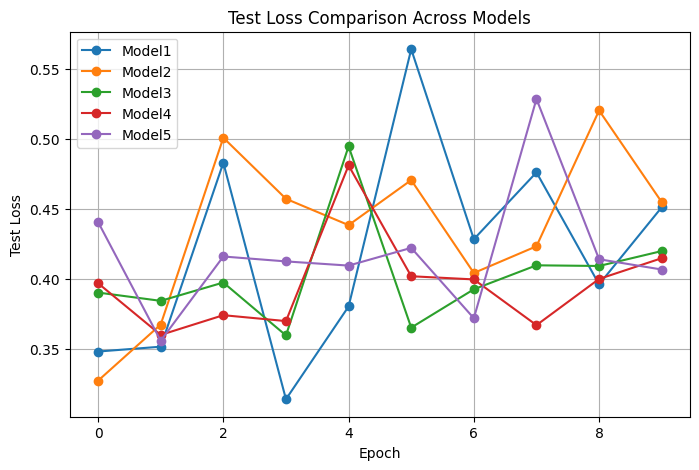

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for name, history in histories.items():
    plt.plot(history["test_loss"], marker='o', label=name)

plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("Test Loss Comparison Across Models")
plt.legend()
plt.grid(True)
plt.show()

### Precision

**Precision** is a metric that measures how many of the samples predicted as positive are actually correct. Based on the confusion matrix, it is defined as:

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

where **TP (True Positives)** are correctly predicted active molecules, and **FP (False Positives)** are molecules predicted as active but are actually inactive.

Precision is especially important in this task because the dataset is highly imbalanced and the goal is to identify molecules that are truly active against HIV. A low precision means that many of the predicted "active" molecules are actually false positives, which could lead to wasted time, cost, and effort in laboratory validation. Therefore, a model with higher precision is more reliable when selecting candidate molecules for further experimental testing.

From the results, **Model4 and Model5 consistently achieve higher precision values compared to the other models, often exceeding 20% across multiple epochs**. This suggests that these models are more reliable when predicting active molecules and are better suited for practical use cases where experimental validation is costly.

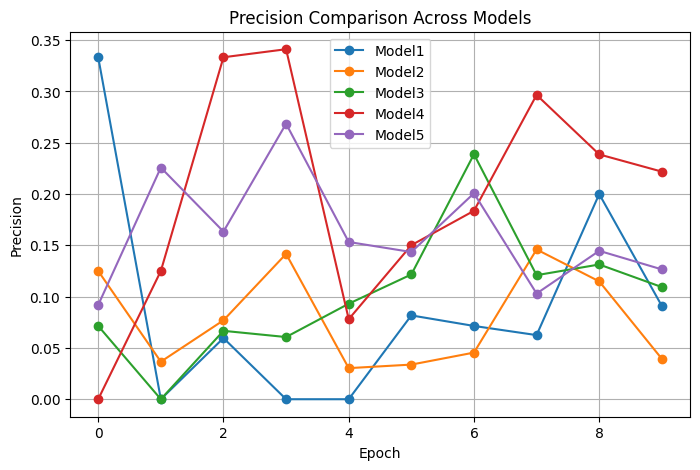

In [31]:
plt.figure(figsize=(8, 5))

for name, history in histories.items():
    plt.plot(history["test_precision"], marker='o', label=name)

plt.xlabel("Epoch")
plt.ylabel("Precision")
plt.title("Precision Comparison Across Models")
plt.legend()
plt.grid(True)
plt.show()

### ROC-AUC

**ROC-AUC (Receiver Operating Characteristic - Area Under the Curve)** is a metric that evaluates the model’s ability to distinguish between classes across all possible classification thresholds.

The ROC curve plots the **True Positive Rate (TPR)** against the **False Positive Rate (FPR)**:
- **TPR (Recall)** = TP / (TP + FN)
- **FPR** = FP / (FP + TN)

The **AUC (Area Under the Curve)** summarizes this curve into a single value between 0 and 1:
- AUC = 1 → perfect classification  
- AUC = 0.5 → random guessing  

ROC-AUC is particularly important in this task because the dataset is highly imbalanced (~3.5% active molecules). Unlike accuracy, ROC-AUC is not affected by class imbalance and provides a more reliable measure of how well the model separates active from inactive molecules.

From the results, **Model5 achieves the highest ROC-AUC values across most epochs, reaching approximately 0.75**, indicating the best overall ability to distinguish between active and inactive molecules. **Model4 also performs relatively well**, while the other models show significantly lower ROC-AUC values.

This suggests that Model5 is the most effective model for identifying potential HIV-active molecules, especially in a screening scenario where distinguishing between classes is critical.

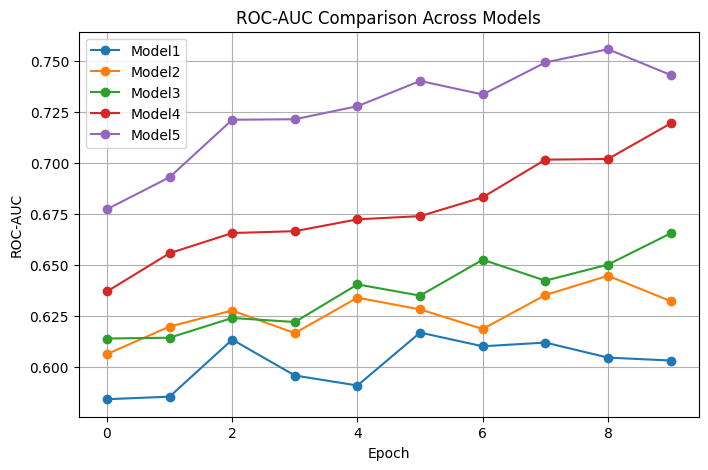

In [33]:
plt.figure(figsize=(8, 5))

for name, history in histories.items():
    plt.plot(history["test_roc_auc"], marker='o', label=name)

plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("ROC-AUC Comparison Across Models")
plt.legend()
plt.grid(True)
plt.show()

## Molecule-Level Examples

To better understand model behavior beyond aggregate metrics, we visualize specific molecular graphs from the test set.

- **True Positives** are molecules correctly predicted as active against HIV.
- **False Positives** are molecules predicted as active although they are actually inactive.

These examples provide an intuitive view of model behavior on individual samples and help illustrate the practical strengths and weaknesses of each architecture.

In [40]:
import torch
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx
from IPython.display import display

def get_predictions(model, loader, device):
    model.eval()

    all_graphs = []
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            out = model(batch.x.float(), batch.edge_index, batch.batch)
            probs = torch.softmax(out, dim=1)[:, 1]
            preds = (probs > 0.5).long()

            graphs = batch.to_data_list()

            # supports both shape [batch] and [batch,1]
            y = batch.y.view(-1).long()

            for g, p, prob, label in zip(graphs, preds.cpu(), probs.cpu(), y.cpu()):
                all_graphs.append(g)
                all_preds.append(int(p))
                all_probs.append(float(prob))
                all_labels.append(int(label))

    return all_graphs, all_preds, all_labels, all_probs


def split_examples(graphs, preds, labels):
    tp, fp, fn, tn = [], [], [], []

    for g, p, y in zip(graphs, preds, labels):
        if p == 1 and y == 1:
            tp.append(g)
        elif p == 1 and y == 0:
            fp.append(g)
        elif p == 0 and y == 1:
            fn.append(g)
        else:
            tn.append(g)

    return tp, fp, fn, tn


def visualize_graph_examples(graphs, title, max_graphs=6):
    n = min(len(graphs), max_graphs)

    if n == 0:
        print(f"{title}: no examples found")
        return

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    axes = axes.flatten()

    for ax in axes[n:]:
        ax.axis("off")

    for i in range(n):
        g = graphs[i]
        G = to_networkx(g, to_undirected=True)

        ax = axes[i]
        pos = nx.spring_layout(G, seed=42)

        nx.draw(
            G,
            pos,
            ax=ax,
            with_labels=False,
            node_size=80,
            width=1.0
        )

        ax.set_title(f"Example {i+1}")
        ax.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

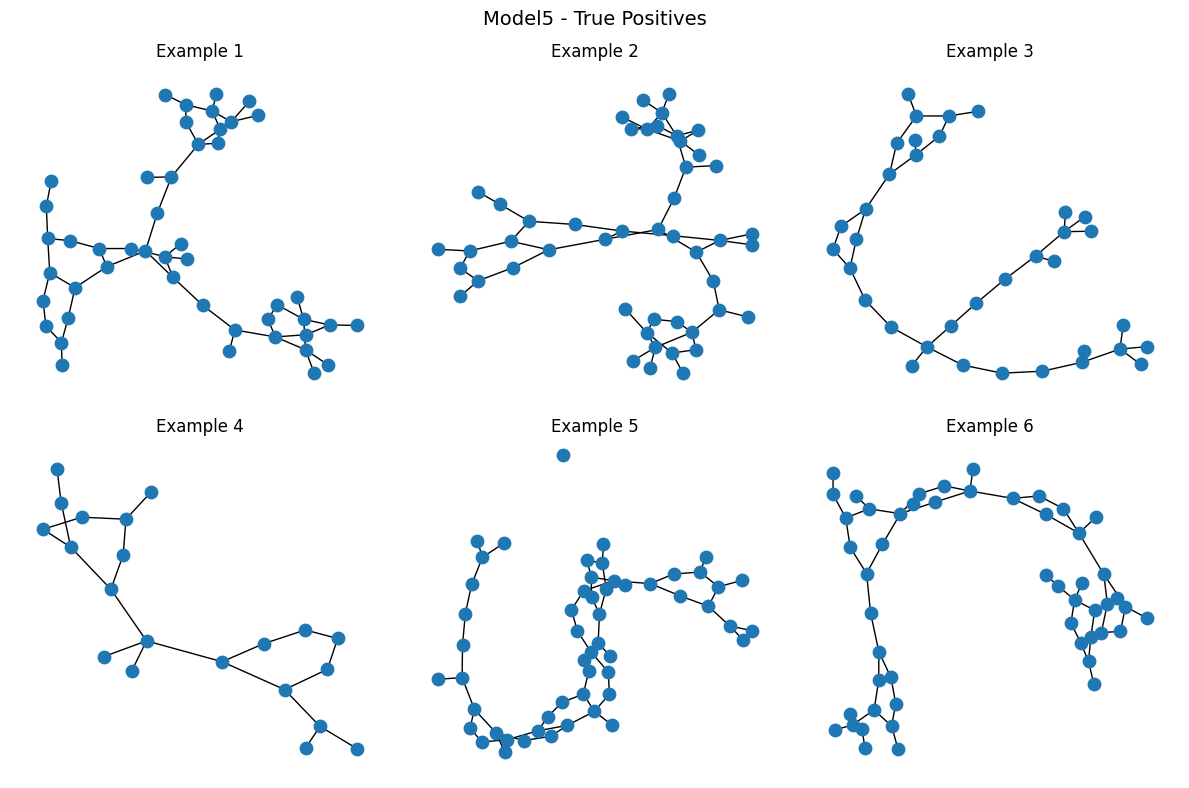

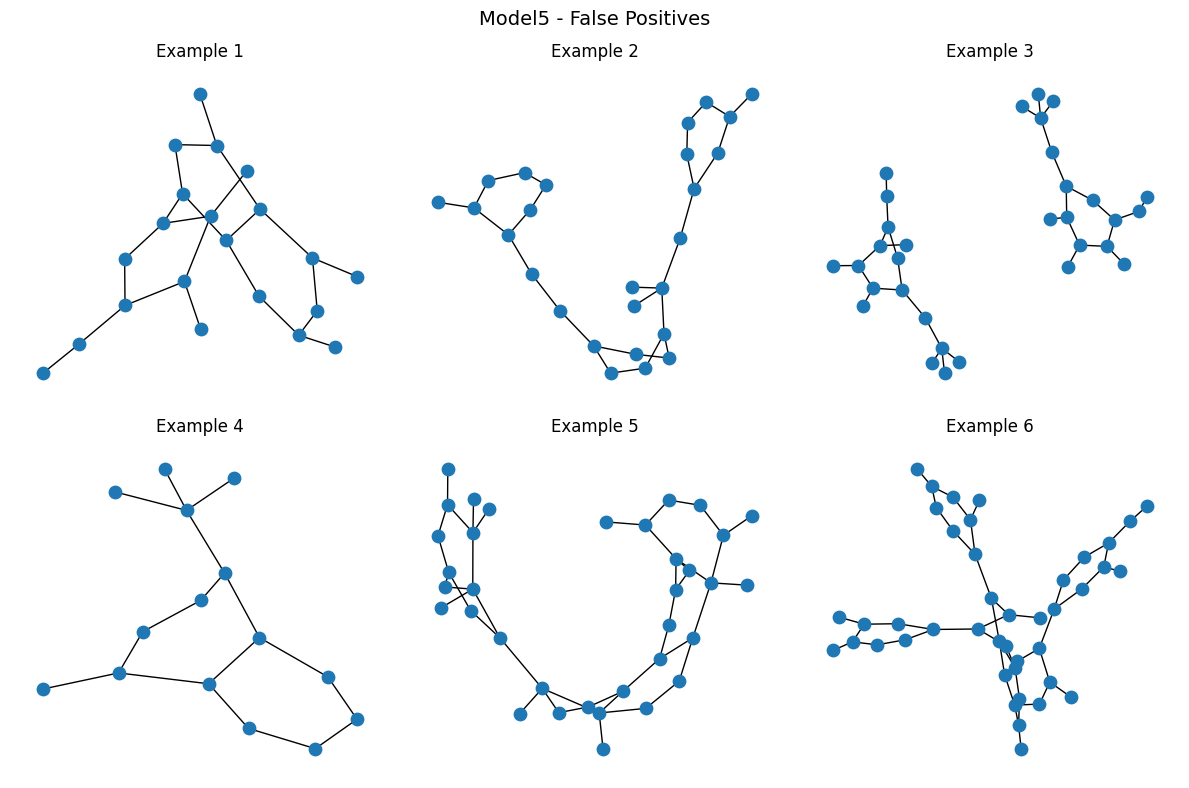

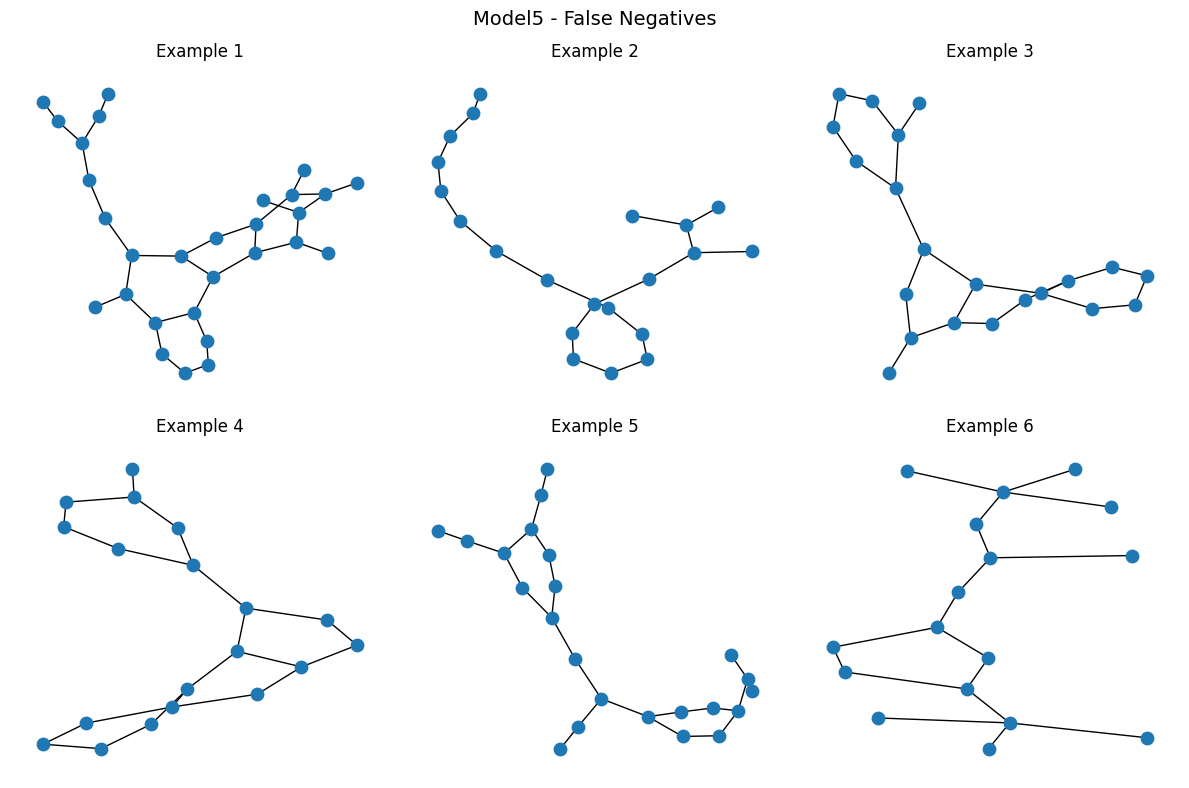

In [43]:
model_name = "Model5"
model = results[model_name]["model"]

graphs, preds, labels, probs = get_predictions(model, test_loader, device)
tp, fp, fn, tn = split_examples(graphs, preds, labels)

visualize_graph_examples(tp, f"{model_name} - True Positives")
visualize_graph_examples(fp, f"{model_name} - False Positives")
visualize_graph_examples(fn, f"{model_name} - False Negatives")

### Conclusion

Among the tested architectures, Model5 achieved the best overall discrimination ability according to ROC-AUC, while Model4 and Model5 showed the best precision values.  
This suggests that deeper or better-regularized graph representations improve the ability to separate active from inactive molecules.  
However, due to the strong class imbalance, the loss curves were not strongly informative, and metrics such as ROC-AUC and precision were more useful for evaluation.

In addition, examining specific molecular examples helps reveal where the models succeed and where they still fail, especially in terms of false positive predictions.